In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns

import sklearn

# Problem presentation
Same problem as the logistic regression, but we change the ML model used. We try to determine whether there is snow or not at the Folgefonna skisenter based on other weather variables.

# STEP 01 PREPROCESSING DATA
The data is loaded with pandas, a library allowing to extract data from csv table files.


## Load data from file
The numpy array are provided in X_data and y_data variables

In [2]:
df = pd.read_csv('../data/folgefonna-skisenter_vaeret.csv', index_col=0)
df=df.dropna()

In [3]:
X = df[['Tmin','wind','Pr','Tmax']].values
y = df[['Snowdepth']].values

We **binarize** the y data so it is 1 when the snow is above 0.1 and 0 otherwise.

In [4]:
y = sklearn.preprocessing.Binarizer(threshold=0.1).fit_transform(y).reshape(-1)

## **QUESTION 1**: Create train, validation and test datasets from `X` and `y`.

In [ ]:
X_train, X_valtest, y_train, y_valtest = ...
X_val, X_test, y_val, y_test = ...

### Plot example data
We plot a subset of the data on a 2d space. The colors represent the presence of snow.

Text(39.858819444444435, 0.5, 'Wind')

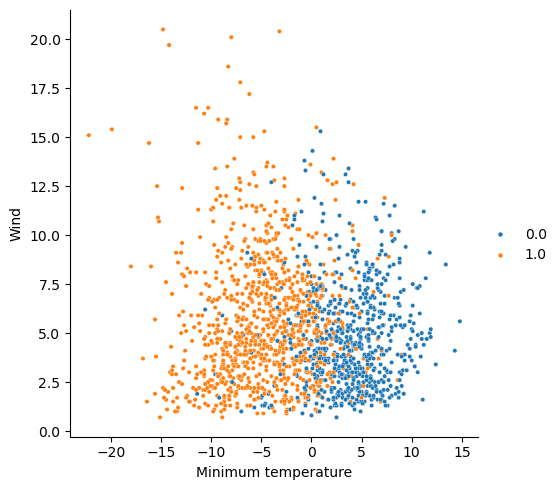

In [6]:
sns.relplot(x=X_train[:,0], 
            y=X_train[:,1],
            hue=y_train[:],
            s=10
           )
plt.xlabel('Minimum temperature')
plt.ylabel('Wind')

# STEP 2: Define ML model and fit it to the data


## **QUESTION 2**: Define the DecisionTree model by creating the object `model` in the following cell.
There is one hyperparameter we can change here: `max_depth`, it corresponds to the number of sequential splits that we do. Choose what you feel appropriate.

In [ ]:
max_depth = ...
model = ...

## Step 2.2: Fit the model to the data
Once we have defined the model, we will fit the model to the data. The model will change some internal coefficients to link the X and Y datasets.

## **QUESTION 3**: Fit the model to the **training data** in the following cell.

In [ ]:
...

## Plot the tree

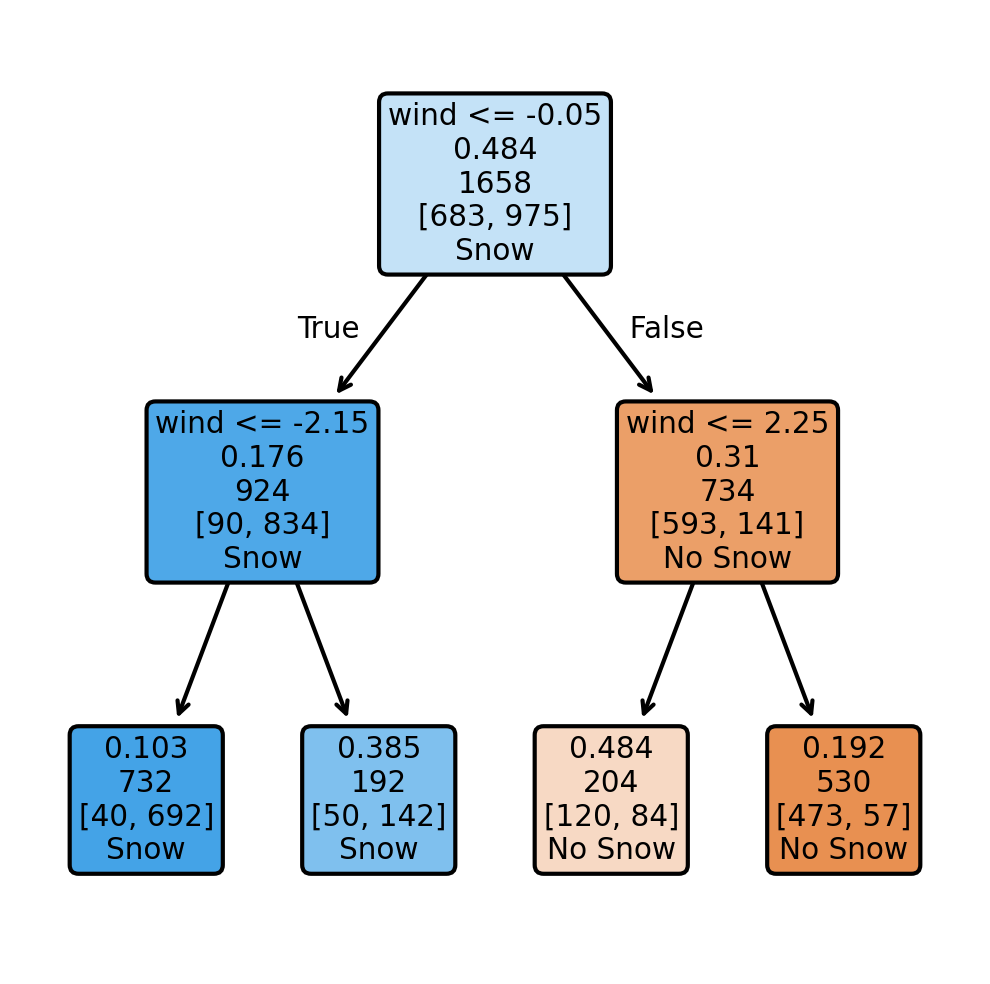

In [9]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)
sklearn.tree.plot_tree(model, 
                       feature_names=['wind','Pr','Tmax'],
                       filled=True, rounded=True,ax=ax, class_names=['No Snow','Snow'],
                       label='none');

# STEP 3: Make predictions and evaluate the model skill
Once the model is fitted to the data, we can use it to make predictions.

## Step 3.1: Predict `y` from `X`
We predict the values of `y` from `X` based on the relation learned by the model.

## **QUESTION 4**: Use the **validation data** to make predictions.

In [ ]:
y_val_predictions = ...

## Evaluate the results with `accuracy` and confusion matrix
We compute the confusion matrix and the accuracy

## **QUESTION 5**: Compute the confusion matrix of the validation data.

In [ ]:
confusion_matrix = ...

We now visualize the confusion matrix

[Text(0.5, 0, 'No Snow'), Text(1.5, 0, 'Snow')]

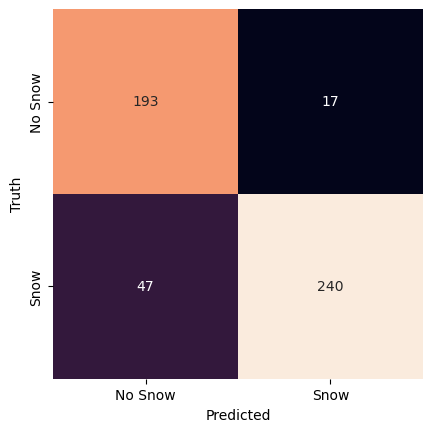

In [12]:
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix, square=True, cbar=False, annot=True, fmt='.0f',ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Truth')
ax.set_yticklabels(['No Snow','Snow'])
ax.set_xticklabels(['No Snow','Snow'])

## **QUESTION 6**: Compute the accuracy of the model.

In [ ]:
accuracy = ...

print(f"Accuracy: {accuracy:.02f}")


## **QUESTION 7**: Change the number of sequential splits and compare results.
Is there an optimal number of splits? You can plot the accuracy compared to the depth of the tree.

In [ ]:
...

## **QUESTION 8**: Compare the performance with the logistic regression

In [ ]:
...